# Connectomes

## Libraries and DLL Injections for WSL2 with GPU passthrough

In [ ]:
import os
import ctypes

Inject libnvrtc and libnvrtc-builtins

In [19]:
site_pkg = os.path.join("/mnt/d/Connectomes/Connectome_Analysis/", ".venv/lib/python3.12/site-packages")

# Define the hidden CUDA library paths
cuda_paths = [
    os.path.join(site_pkg, "nvidia/cu13/lib"),
    "/usr/lib/wsl/lib"  # Vital for WSL2 GPU passthrough
]

# Inject into the environment
existing_ld = os.environ.get("LD_LIBRARY_PATH", "")
os.environ["LD_LIBRARY_PATH"] = ":".join(cuda_paths) + (":" + existing_ld if existing_ld else "")

# Critical: In some environments, we must 'force' the load of the built-ins
try:
    libnvrtc = os.path.join(site_pkg, "nvidia/cu13/lib/libnvrtc.so.13")
    builtins = os.path.join(site_pkg, "nvidia/cu13/lib/libnvrtc-builtins.so.13.0")
    ctypes.CDLL(libnvrtc, mode=ctypes.RTLD_GLOBAL)
    ctypes.CDLL(builtins, mode=ctypes.RTLD_GLOBAL)
    print("✅ Successfully injected libnvrtc and libnvrtc-builtins into process memory.")
except Exception as e:
    print(f"❌ Manual injection failed: {e}")

import cupy as cp
import networkx as nx

print(f"✅ CuPy loaded from: {cp.__file__}")
print(f"🚀 GPU Device: {cp.cuda.Device(0).attributes['MultiProcessorCount']} multiprocessors found.")

✅ Successfully injected libnvrtc and libnvrtc-builtins into process memory.
✅ CuPy loaded from: /mnt/d/Connectomes/Connectome_Analysis/.venv/lib/python3.12/site-packages/cupy/__init__.py
🚀 GPU Device: 14 multiprocessors found.


Library Imports

In [ ]:
import gzip
import shutil

import matplotlib.pyplot as plt
import networkx as nx
import nx_parallel
import numpy as np
import pandas as pd

Customise NetworkX behaviour

In [2]:
# This checks what backends NetworkX actually detected at startup
print("Available backends:", nx.config.backends)

Available backends: Config(cugraph=Config(use_compat_graphs=True), parallel=ParallelConfig(active=True, backend='loky', n_jobs=-1, verbose=0, temp_folder=None, max_nbytes='1M', mmap_mode='r', prefer=None, require=None, inner_max_num_threads=None, backend_params={}))


In [3]:
# Set priority backends
nx.config.backend_priority = ["parallel", "cugraph"]

In [4]:
# Filter out cache warnings
nx.config.warnings_to_ignore.add("cache")

## Load Networks

In [21]:
mouse_net = nx.read_graphml("data/graphml/mouse_brain_1.graphml")
fly_net = nx.read_graphml("data/graphml/drosophila_medulla_1.graphml")

In [22]:
if not os.path.exists('data/csv/connections_princeton.csv'):
    with gzip.open('data/csv/archive/connections_princeton.csv.gz', 'rb') as f_in:
        with open('data/csv/connections_princeton.csv', 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)

In [23]:
if not os.path.exists('data/csv/processed_labels.csv'):
    with gzip.open('data/csv/archive/processed_labels.csv.gz', 'rb') as f_in:
        with open('data/csv/processed_labels.csv', 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)

> ⚠️ RUN `git lfs pull` before running the following cell.

In [ ]:
!git lfs pull

In [24]:
fafb_connections = pd.read_csv('data/csv/connections_princeton.csv', header=0)
fafb_net = nx.from_pandas_edgelist(fafb_connections, source='pre_root_id', target='post_root_id', edge_key='neuropil', edge_attr=True, create_using=nx.MultiDiGraph()) # pyright: ignore[reportArgumentType, reportCallIssue]

In [25]:
print(f"Number of nodes in Mouse: {mouse_net.number_of_nodes()}")
print(f"Number of edges in Mouse: {mouse_net.number_of_edges()}")

print(f"Number of nodes in Fly: {fly_net.number_of_nodes()}")
print(f"Number of edges in Fly: {fly_net.number_of_edges()}")

Number of nodes in Mouse: 213
Number of edges in Mouse: 21807
Number of nodes in Fly: 1781
Number of edges in Fly: 33641


In [26]:
print(f"Number of nodes in Female Adult Fly Brain: {fafb_net.number_of_nodes()}")
print(f"Number of edges in Female Adult Fly Brain: {fafb_net.number_of_edges()}")

Number of nodes in Female Adult Fly Brain: 138584
Number of edges in Female Adult Fly Brain: 5342446


## Network Plot

In [ ]:
fig, ax = plt.subplots(figsize=(16, 10), dpi=300)

pos = nx.spring_layout(mouse_net, seed=42, k=1, iterations=50)
nx.draw_networkx_edges(mouse_net, pos, alpha=0.5, edge_color='gray', ax=ax)
nx.draw_networkx_nodes(mouse_net, pos, node_size=85, node_color='tab:blue', alpha=0.7, ax=ax)

ax.set_title("Mouse Brain Connectome", fontsize=16, pad=20, fontweight='bold')
fig.savefig("viz/mouse_brain_connectome.png")
plt.close(fig)

In [ ]:
fig, ax = plt.subplots(figsize=(16, 10), dpi=300)

pos = nx.spring_layout(fly_net, seed=42, k=1, iterations=50)
nx.draw_networkx_edges(fly_net, pos, alpha=0.5, edge_color='gray', ax=ax)
nx.draw_networkx_nodes(fly_net, pos, node_size=85, node_color='tab:blue', alpha=0.7, ax=ax)

ax.set_title("Fly Brain Connectome ", fontsize=16, pad=20, fontweight='bold')
fig.savefig("viz/fly_brain_connectome.png")
plt.close(fig)

## Network Level Properties

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
degree_sequence = sorted([d for n, d in mouse_net.degree()], reverse=True)
degree_count = np.bincount(degree_sequence)
degrees = np.arange(len(degree_count))
ax.bar(degrees, degree_count)
ax.set_xlabel("Degree")
ax.set_ylabel("Frequency")
# ax.set_xscale("log")
# ax.set_yscale("log")
ax.set_title("Degree Distribution of Mouse Brain Connectome Network")
fig.savefig("viz/degree_dist/mouse_degree_distribution.png")
plt.close(fig)

In [16]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
degree_sequence = sorted([d for n, d in fly_net.degree()], reverse=True)
degree_count = np.bincount(degree_sequence)
degrees = np.arange(len(degree_count))
ax.bar(degrees, degree_count)
ax.set_xlabel("Degree")
ax.set_ylabel("Frequency")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Degree Distribution of Fly Brain Connectome Network")
fig.savefig("viz/degree_dist/fly_degree_distribution.png")
plt.close(fig)

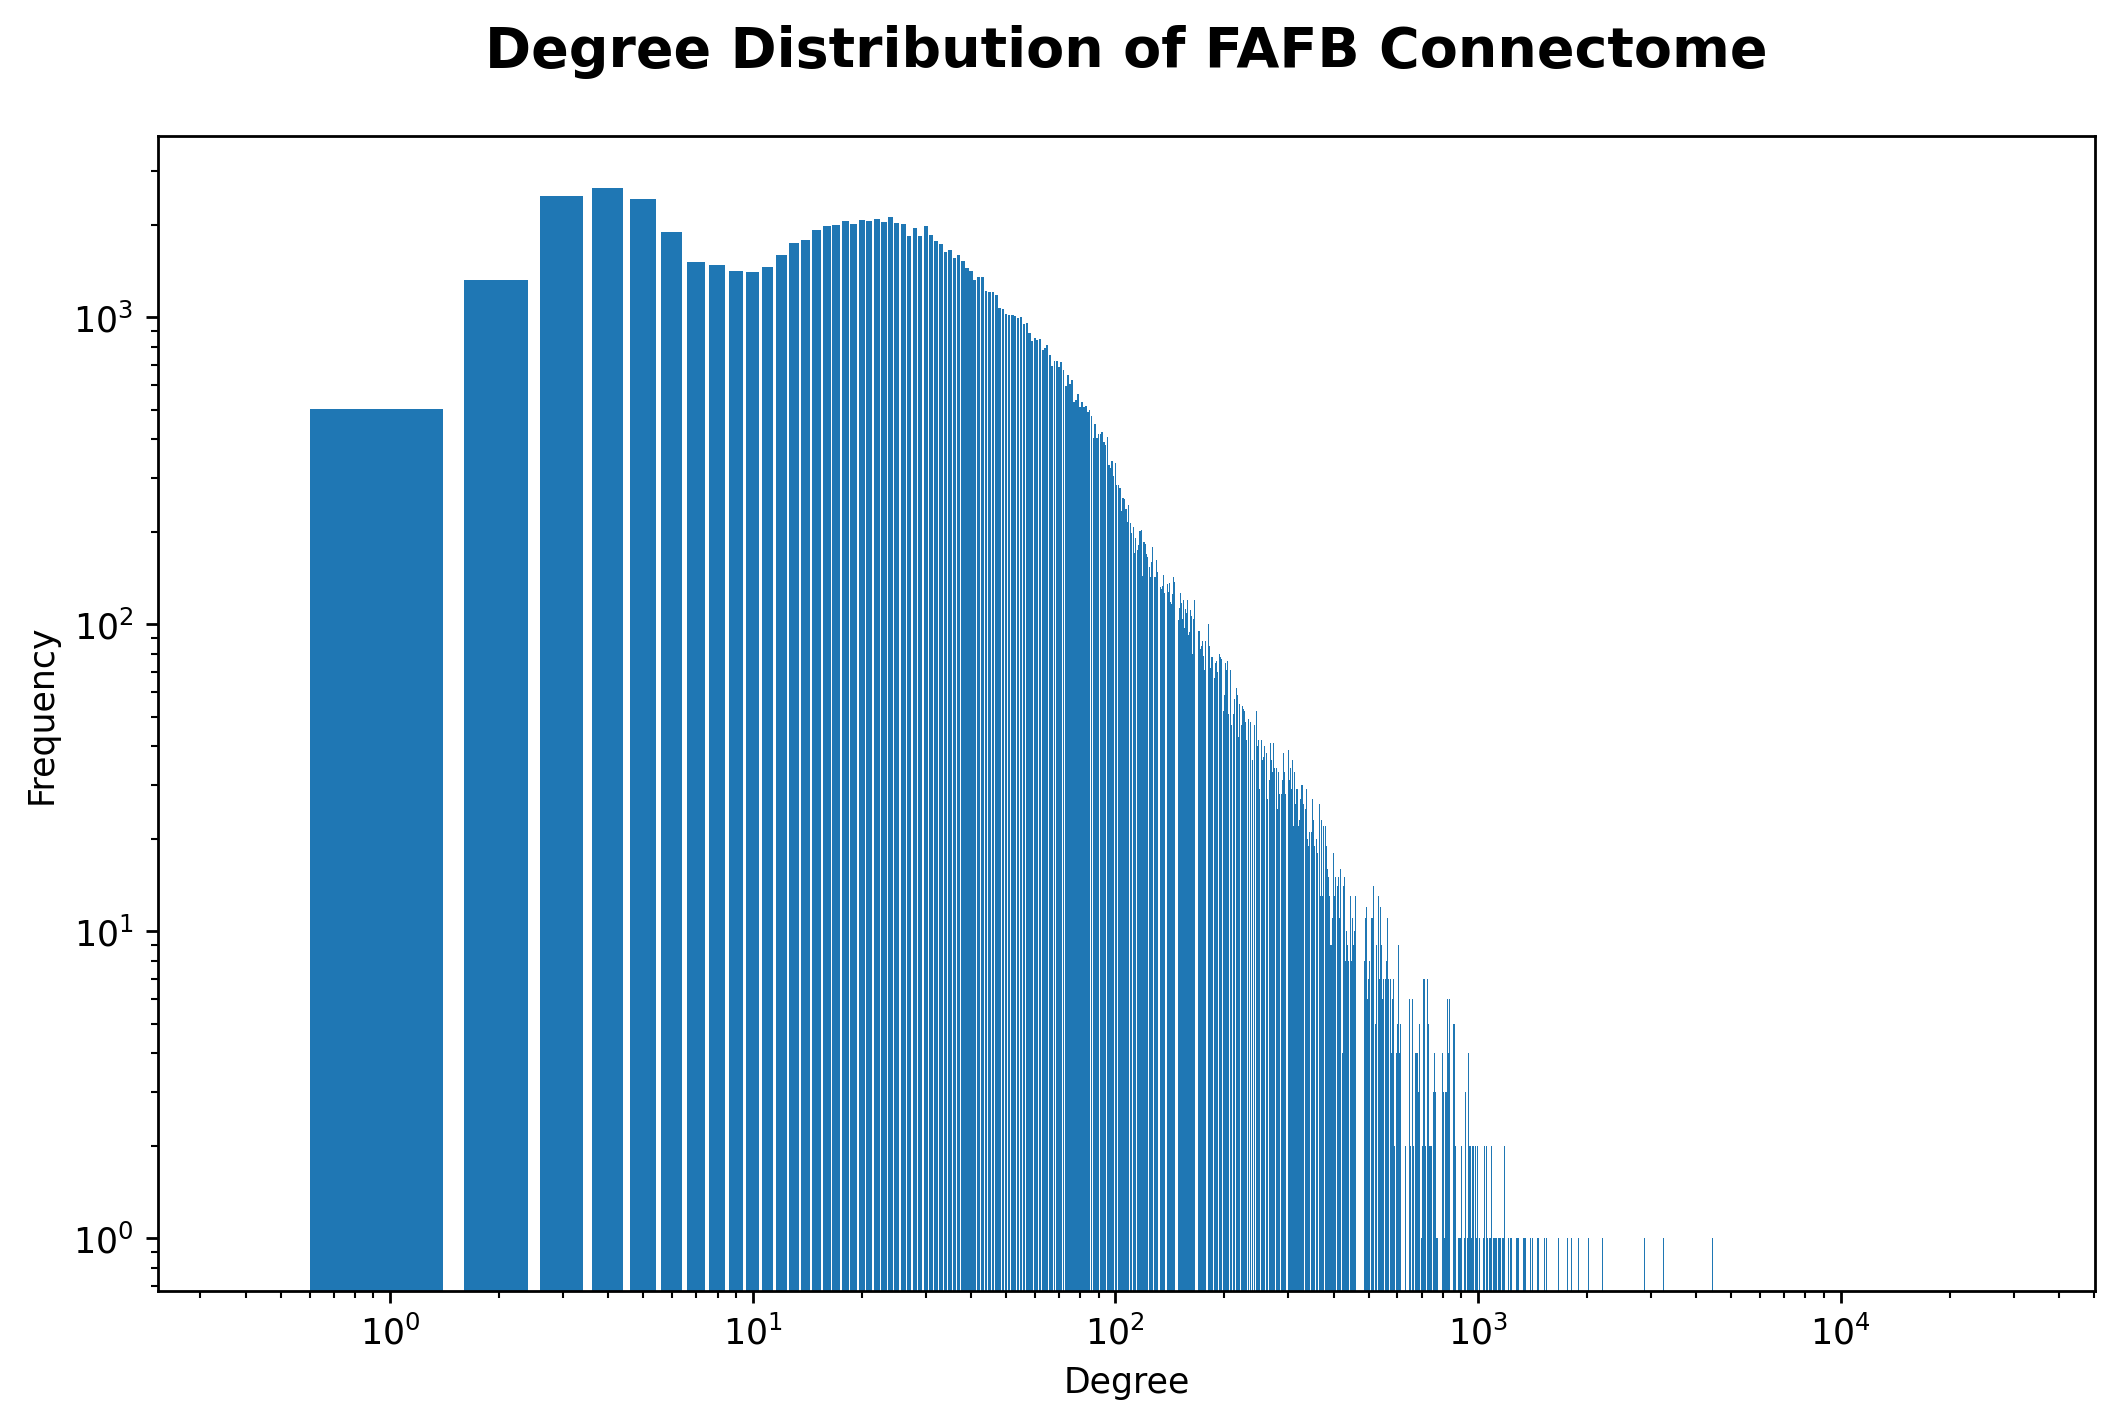

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=250)
degree_sequence = sorted([d for n, d in fafb_net.degree()], reverse=True)
degree_count = np.bincount(degree_sequence)
degrees = np.arange(len(degree_count))
ax.bar(degrees, degree_count)
ax.set_xlabel("Degree")
ax.set_ylabel("Frequency")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Degree Distribution of FAFB Connectome", fontsize=16, pad=20, fontweight='bold')
fig.savefig("viz/degree_dist/fafb_degree_distribution.png")
plt.close((fig))

In [ ]:
print(f"Average degree of FAFB Connectome: {nx.number_of_edges(fafb_net)/nx.number_of_nodes((fafb_net)):.2f}")

Average degree of FAFB Connectome: {476: 78.11817226890756, 22: 302.8490438646165, 66: 216.5063955130533, 59: 223.9505311815749, 40: 278.6684675141243, 34: 318.8796594236957, 28: 310.57465366854797, 54: 211.87037037037038, 19: 301.99204527672003, 38: 298.0465321215053, 120: 127.97522401433692, 450: 87.76197530864198, 76: 197.04153354632587, 46: 239.21694325961505, 57: 227.2314870947001, 42: 255.5859896219422, 58: 210.39441837011753, 60: 210.61664726426076, 87: 182.56726847494366, 117: 136.7737381468725, 74: 209.67573823823824, 79: 198.72678013355218, 17: 285.55321285140565, 18: 315.34974135143875, 26: 304.4069843092231, 400: 88.12777777777778, 64: 207.23004234629863, 43: 258.29476313522827, 280: 103.02128571428571, 89: 184.59503281788852, 290: 107.21443965517241, 25: 295.1768421052632, 98: 156.96140456182474, 44: 257.57116979158883, 522: 68.0992337164751, 81: 205.55609030248075, 21: 311.174956762366, 23: 312.1725112040951, 29: 331.26595624929644, 67: 221.24182555430937, 135: 122.478251

In [38]:
nx.degree_centrality(fafb_net, backend=None)

{720575940625363947: 0.003434764725832173,
 720575940623224444: 0.0001587496301855206,
 720575940630432382: 0.00047624889055656173,
 720575940618518557: 0.0004257376445884416,
 720575940627314521: 0.0002886356912464011,
 720575940626337738: 0.0002453403375594409,
 720575940620280405: 0.00020204498387248074,
 720575940620204726: 0.00038965818318264145,
 720575940636942447: 0.0001371019533420405,
 720575940613789411: 0.000274203906684081,
 720575940608359298: 0.0008659070737392032,
 720575940613493733: 0.003247151526522012,
 720575940640167477: 0.000548407813368162,
 720575940629440518: 0.0003319310449333612,
 720575940622800116: 0.0004113058600261215,
 720575940628108309: 0.0003030674758087211,
 720575940637518960: 0.00041852175230728156,
 720575940614827922: 0.0004329535368696016,
 720575940615643835: 0.0006277826284609223,
 720575940617065659: 0.0008442593968957231,
 720575940613448677: 0.000533976028805842,
 720575940636147380: 0.0005700554902116421,
 720575940628260625: 0.0001226701

In [ ]:
print(f"Average out-degree of FAFB Connectome: {sum(nx.out_degree_centrality(fafb_net, backend=None)/len(fafb_net)):.2f}")

In [27]:
mouse_net.__networkx_cache__.clear()

In [ ]:
%%time
apsp_parallel = nx.all_pairs_shortest_path_length(fafb_net, backend='parallel')
list(apsp_parallel)

In [ ]:
%%time
apsp_gpu = nx.all_pairs_shortest_path_length(fafb_net, backend='cugraph')
list(apsp_gpu)

CPU times: user 2.11 s, sys: 211 ms, total: 2.32 s
Wall time: 2.31 s


[('n0',
  {'n0': 0,
   'n1': 2,
   'n2': 2,
   'n3': 2,
   'n4': 2,
   'n5': 2,
   'n6': 2,
   'n7': 1,
   'n8': 2,
   'n9': 2,
   'n10': 2,
   'n11': 1,
   'n12': 2,
   'n13': 1,
   'n14': 1,
   'n15': 1,
   'n16': 2,
   'n17': 2,
   'n18': 2,
   'n19': 2,
   'n20': 2,
   'n21': 2,
   'n22': 2,
   'n23': 2,
   'n24': 2,
   'n25': 2,
   'n26': 1,
   'n27': 2,
   'n28': 1,
   'n29': 2,
   'n30': 2,
   'n31': 1,
   'n32': 1,
   'n33': 2,
   'n34': 2,
   'n35': 2,
   'n36': 2,
   'n37': 2,
   'n38': 1,
   'n39': 2,
   'n40': 2,
   'n41': 2,
   'n42': 2,
   'n43': 1,
   'n44': 1,
   'n45': 2,
   'n46': 2,
   'n47': 2,
   'n48': 1,
   'n49': 2,
   'n50': 2,
   'n51': 2,
   'n52': 2,
   'n53': 2,
   'n54': 2,
   'n55': 1,
   'n56': 2,
   'n57': 2,
   'n58': 2,
   'n59': 2,
   'n60': 2,
   'n61': 1,
   'n62': 2,
   'n63': 1,
   'n64': 1,
   'n65': 2,
   'n66': 2,
   'n67': 2,
   'n68': 2,
   'n69': 2,
   'n70': 2,
   'n71': 1,
   'n72': 1,
   'n73': 2,
   'n74': 1,
   'n75': 1,
   'n76': 2,
 